# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [ ]:
Run_All = true
Estou_Com_Mt_Tempo = false
# Vai demorar

if Run_All
    qtt_testes = 200
    qtt_in_k = 9
else
    qtt_testes = 100
    qtt_in_k = 8
end
nothing

In [2]:
# Código
using LinearAlgebra
using Plots
# using Random
# Random.seed!(42)
nothing

In [3]:
function produtorio_sem_i(v::AbstractArray, u::Vector, pos)
    return v' * u - v[pos] * u[pos]
end

function norma(v::Vector)
    return sqrt(v' * v)
end
nothing

In [4]:
function raio_espectral(A::Matrix)
    return maximum(abs.(eigvals(A)))    
end
nothing

In [6]:
function novo_chute_jacobi!(A::Matrix, v::Vector, cur::Vector, chute::Vector, pos::Int)
    chute[pos] = (v[pos] - produtorio_sem_i(@views(A[pos, :]), cur, pos)) / A[pos, pos]
end

function Jacobi(A::Matrix, v::Vector, eps)
    chute::Vector = zeros(size(v,1))
    cur::Vector = copy(chute)
    m, n = size(A)
    erros = Float64[]

    for _ in 1:1000
        for i in 1:m
            novo_chute_jacobi!(A, v, cur, chute, i)
        end
        push!(erros, norma(A * chute - v))
        if erros[end] < eps
            return chute, erros
        end
        cur = copy(chute)
    end
    return chute, erros
end

nothing

In [ ]:
function JacobiMatrix(A::Matrix)
    D = Diagonal(diag(A))

    Mj = -D \ (A - D)

    return Mj
end

if Estou_Com_Mt_Tempo
    function JacobiConverge(A::Matrix)
        return raio_espectral(JacobiMatrix(A))
    end
else 
    function JacobiConverge(A::Matrix)
        T = JacobiMatrix(A)
        return min(norm(T, Inf), norm(T, 1))
    end
end
nothing

In [8]:
function novo_chute_gs!(A::Matrix, v::Vector, chute::Vector, pos::Int)
    chute[pos] = (v[pos] - produtorio_sem_i(@views(A[pos, :]), chute, pos)) / A[pos, pos]
end

function GaussSiedel(A::Matrix, v::Vector, eps)
    chute::Vector = zeros(size(v,1))
    m, n = size(A)
    erros = Float64[]

    for _ in 1:1000
        for i in 1:m
            novo_chute_gs!(A, v, chute, i)
        end
        push!(erros, norma(A * chute - v))
        if erros[end] < eps
            return chute, erros
        end
    end
    return chute, erros
end

nothing

In [ ]:
function GaussSeidelMatrix(A::Matrix)
    LD = tril(A)

    Mgs = - LD \ (A - LD)

    return Mgs
end

if Estou_Com_Mt_Tempo
    function GaussSeidelConverge(A::Matrix)
        return raio_espectral(GaussSeidelMatrix(A))
    end
else
    function GaussSeidelConverge(A::Matrix)
        T = GaussSeidelMatrix(A)
        return min(norm(T, Inf), norm(T, 1))
    end
end
nothing

Qual deveria ser a complexidade computacional do código que você escreveu?

O($k\cdot n^2$), com k sendo a quantidade de iterações


## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [9]:
function grafico(JE::Vector, GsE::Vector)
    plot(1:length(JE), JE, marker=:circle, label="Jacobi", xlabel="Iteração", ylabel="Erro", yaxis=:log)
    plot!(1:length(GsE), GsE, marker=:diamond, label="Gauss-Seidel", yaxis=:log)
end

function graficoseparado(v::Vector, l)
    plot(1:length(v), v, marker=:circle, label=l, xlabel="Iteração", ylabel="Erro", yaxis=:log)
end

nothing

In [10]:
function test_matrix_separado(A::Matrix, v::Vector, f, l)
    _, u = f(A, v, 10^(-12))
    graficoseparado(u, l)
end

function test_matrix(A::Matrix, v::Vector)
    J, JE   = Jacobi(A, v, 10^(-12))
    Gs, GsE = GaussSiedel(A, v, 10^(-12))
    
    grafico(JE, GsE)
end

function test_random_matrix(m::Int)
    A = rand(m,m) + m * I(m)
    v = rand(m)
    
    test_matrix(A, v)
end

nothing

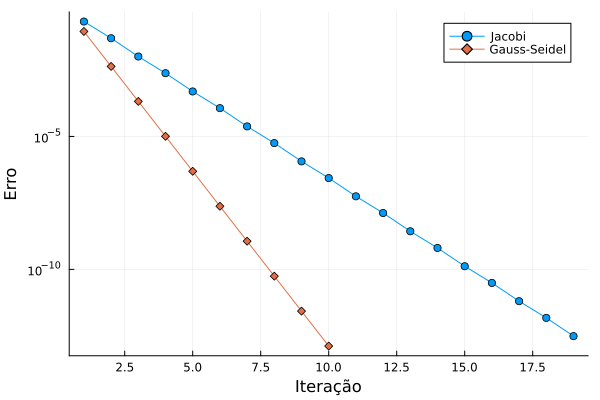

In [11]:
test_random_matrix(2)

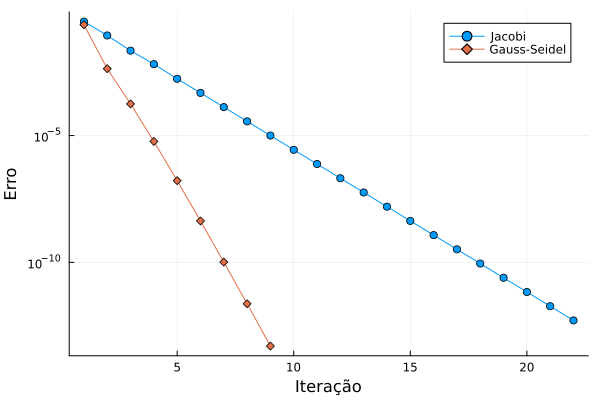

In [12]:
test_random_matrix(3)

Na grande maioria das matrizes, Gauss Seidel converge mais rápido, Geralmente, com metade dos passos.

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [13]:
function testar_se_matriz_converge(A::Matrix)
    J = JacobiConverge(A) < 1
    Gs = GaussSeidelConverge(A) < 1
    return J && Gs
end

function testar_matrizes(f, tamanho::Int)
    d = 0
    for j in 1:qtt_testes
        if testar_se_matriz_converge(f(tamanho))
            d += 1
        end
    end
    return d / qtt_testes
end

nothing

In [14]:
function randomico(m)
    return rand(m,m)
end

for i in 4:20
    println("$i x $i: Funcionou para $(testar_matrizes(randomico, i) * 100)%")
end

4 x 4: Funcionou para 0.0%
5 x 5: Funcionou para 0.0%
6 x 6: Funcionou para 0.0%
7 x 7: Funcionou para 0.0%
8 x 8: Funcionou para 0.0%
9 x 9: Funcionou para 0.0%
10 x 10: Funcionou para 0.0%
11 x 11: Funcionou para 0.0%
12 x 12: Funcionou para 0.0%
13 x 13: Funcionou para 0.0%
14 x 14: Funcionou para 0.0%
15 x 15: Funcionou para 0.0%
16 x 16: Funcionou para 0.0%
17 x 17: Funcionou para 0.0%
18 x 18: Funcionou para 0.0%
19 x 19: Funcionou para 0.0%
20 x 20: Funcionou para 0.0%


Majoritariamente não

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

$K(m)$ deve estar entre $\sqrt{m}$ e $2 + 2\cdot\sqrt{m}$, pois assim ...!!!###

In [15]:
function testar_matrizes(f, tamanho::Int, k)
    d = 0
    for j in 1:qtt_testes
        if testar_se_matriz_converge(f(tamanho, k))
            d += 1
        end
        if j - d > 0.1 * qtt_testes
            return d / qtt_testes
        end
    end
    return d / qtt_testes
end

function makerand(m, k)
    return randn(m,m) + k * I(m)
end

nothing

In [16]:
function k_inf(m)
    return sqrt(m)
end

function k_sup(m)
    return 2 + 1.05 * sqrt(m)
end

function encontrar_k()
    valores = Float64[]

    for i in 1:qtt_in_k
        m = 2 ^ i
        a = k_inf(m)
        b = k_sup(m)
        k = 0

        print("Calculando k($m): ")
        for _ in 1:50
            k = (a + b)/2

            valor = testar_matrizes(makerand, m, k)
            if abs(valor - 0.95) < 10.0 ^ (-10)
                break
            end
            if valor > 0.95
                b = k
            else
                a = k
            end
        end
        println(k)

        push!(valores, k)
    end

    return valores
end

nothing

In [17]:
pontos_k = encontrar_k()
nothing

Calculando k(2): 2.278189282320552
Calculando k(4): 3.1145915985107417
Calculando k(8): 4.267194598468134
Calculando k(16): 5.349621582031251
Calculando k(32): 7.101541885626668
Calculando k(64): 9.373437499999998
Calculando k(128): 12.596546155318102
Calculando k(256): 17.389062499999998
Calculando k(512): 24.02630853801388


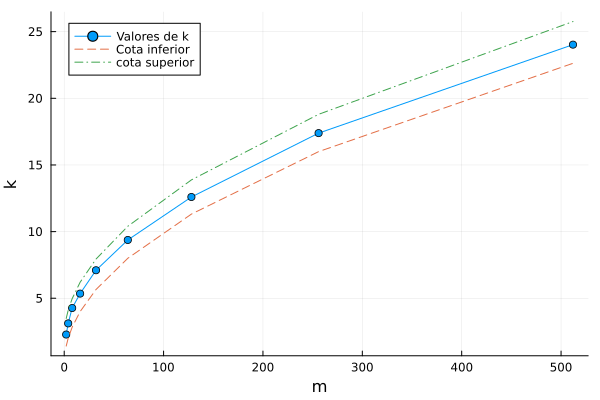

In [18]:
function graficoseparado_linear(v::Vector, l)
    x = 2 .^ (1:length(v))
    plot(x, v, marker=:circle, label=l, xlabel="m", ylabel="k")
    plot!(x, k_inf.(x) , label="Cota inferior", linestyle=:dash)
    plot!(x, k_sup.(x), label="cota superior", linestyle=:dashdot)
end

graficoseparado_linear(pontos_k, "Valores de k")

A velocidade de convergencia é ...!!!###

In [ ]:
function taxa_convergencia(iterados)
    taxas = Float64[]

    for k in 2:length(iterados)-1
        num = norm(iterados[k+1] - iterados[k])
        den = norm(iterados[k] - iterados[k-1])

        if den != 0
            push!(taxas, num / den)
        end
    end

    return taxas
end

nothing

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

Para que Jacobi seja mais rápido, é necessário retirar a vanagem que GS tem sobre ele. Logo podemos pensar numa triangular superior. 
Contudo, nessas matrizes ambas convergem E no mesmo tempo.

Então podemos pensar em adicionar um pouco de erro para o método de Gauss-Seidel. Para isso, pode-se modificar os valores da ultima linha, fazendo com que as iterações das linhas 1 a 3 não se diferencie do método de Jacobi, mas na ultima interação haja grande diferença.

fazendo algumas mudanças a mais para garantir convergencia, pode-se chegar em várias matrizes como a $A$ abaixo


In [20]:
A = [   2  1   0   1
        0  2   1   1 
        0  0   2.1 10
        -1 -10 -10 83
    ]
Norm_A = norm(A, 2)
nothing

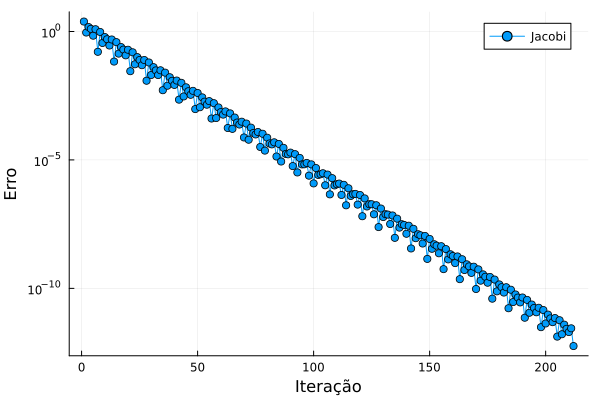

In [21]:
test_matrix_separado(A, rand(4), Jacobi, "Jacobi")

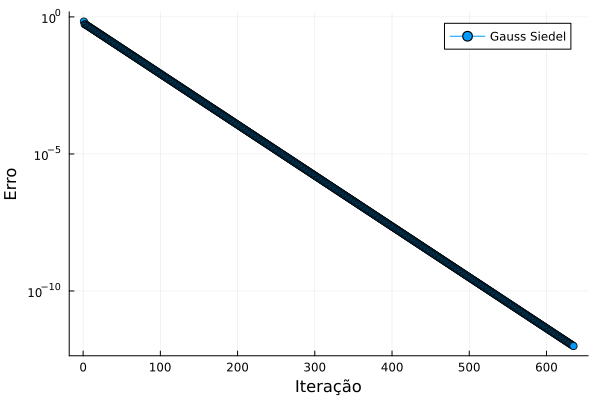

In [22]:
test_matrix_separado(A, rand(4), GaussSiedel, "Gauss Siedel")

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

Definição de matriz pequena usada:
$B$ é matriz pequena em relação a $A$ quando $||B|| \approx ||A|| \times 10^{-2}$

In [23]:
pequena = rand(4,4) * 4 * 10 ^(-1)
println("Norma da matriz pequena dividida pela norma de A: $(norm(pequena) / Norm_A)")

nA = A + pequena
nothing

Norma da matriz pequena dividida pela norma de A: 0.010171856128694708


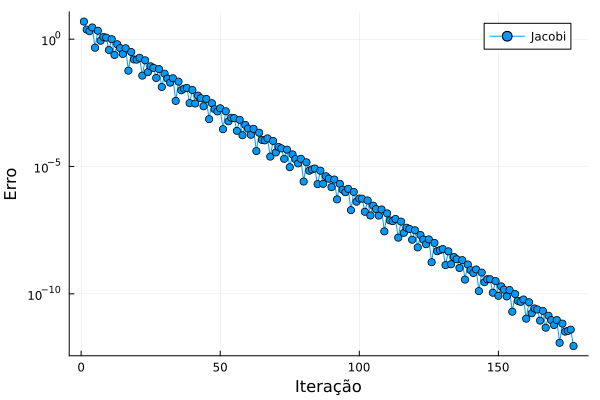

In [24]:
test_matrix_separado(nA, rand(4), Jacobi, "Jacobi")

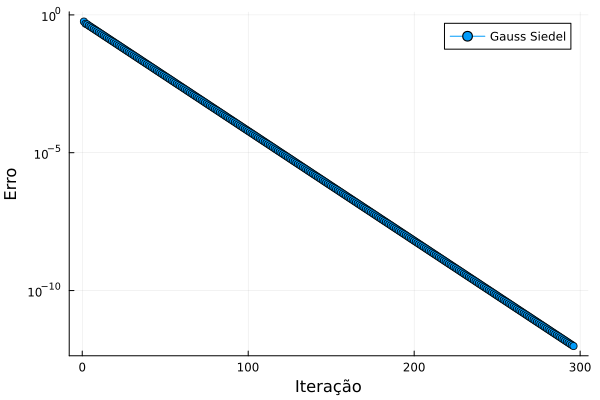

In [25]:
test_matrix_separado(nA, rand(4), GaussSiedel, "Gauss Siedel")

In [26]:
pequenasemdiag = rand(4,4)
pequenasemdiag .-= diag(pequenasemdiag)
println("Norma da matriz pequena (sem diagonal) dividida pela norma de A: $(norm(pequenasemdiag) / Norm_A)")


nA2 = A + pequenasemdiag

Norma da matriz pequena (sem diagonal) dividida pela norma de A: 0.014014401112066283


4×4 Matrix{Float64}:
  2.0        1.31591   -0.307808   1.53472
  0.299236   2.0        0.626151   1.30644
  0.233187  -0.342301   2.1        9.97312
 -0.733426  -9.92763   -9.39741   83.0

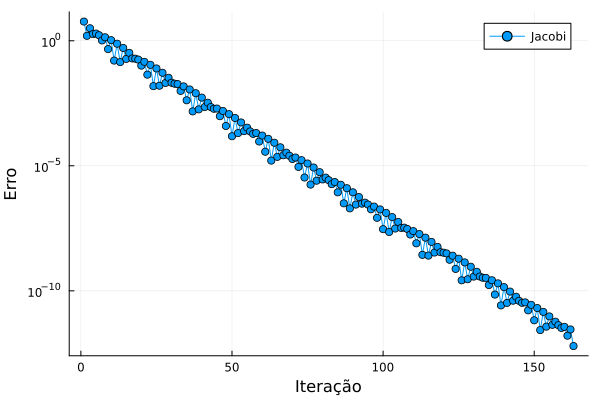

In [27]:
test_matrix_separado(nA2, rand(4), Jacobi, "Jacobi")

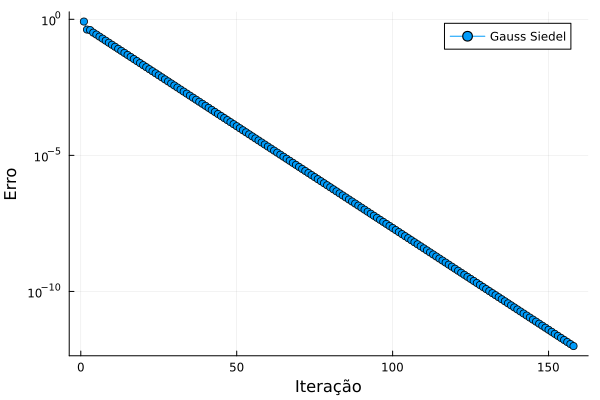

In [28]:
test_matrix_separado(nA2, rand(4), GaussSiedel, "Gauss Siedel")

Quando a diagonal é modificada, ambos os métodos convergem muito mais rápido, convergindo em um mesmo número de iterações (100~150).

Contudo, quando a edição ocorre apenas fora da diagonal, A mudança é muito menos perceptivel no método de Jacobi, se mantendo na quantidade vista no item E. Contudo, o método de Gauss passa a convergir com métade dos passos em relação ao item E.

Interessante: Como não se está mexendo na diagonal, pode ser que a mudança faça com que as métodos não funcionem